# Application - Color quantisation
## Demonstrates the application of the KMeans clustering algorithm for color quantization of an image

Imagine an image with millions of unique colors. Color quantization might reduce this palette to a few dozen colors by grouping similar shades together. This reduction makes the image easier to store, transmit, and process, while ideally retaining enough color fidelity for the human eye to perceive it similarly.

Import all the libraries we will use:

Numpy
Matplotlib.pyplot
shuffle from sklearn.utils
KMeans from sklearn.cluster


*   Numpy
*   Matplotlib
*   shuffle from sklearn.utils
*   KMeans from sklearn.clusterm
*   cv2

In [1]:
# Import listed libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.cluster import KMeans
import cv2

Load a sample image from [sklearn.datasets](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_sample_image.html#sklearn.datasets.load_sample_image) (e.g. 'flower.jpg').

In [2]:
# Load the package
from sklearn.datasets import load_sample_image
# and read the image "flower.jpg"
image = load_sample_image('flower.jpg')

###1. Preprocessing

1.1 Check the type of the data/variable.

In [6]:
image.dtype

dtype('uint8')

1.2 What is the shape (dimentions) of the image?  Set(w = width, h = height, and d = number of channels (dimentions/rbg))

In [7]:
w, h, d = original_shape = tuple(image.shape)
original_shape

(427, 640, 3)

1.3 Convert the image (which is an integer arry) to float64.

In [8]:
image_float = image.astype('float64')

1.4 [Normalise](https://stackoverflow.com/questions/54666507/fast-image-normalisation-in-python) the image to [0,1]: HINT an integer arry is in [0,225] range.

In [9]:
norm_image = (image_float - np.min(image_float)) / (np.max(image_float) - np.min(image_float))

1.5 Display the normalised image (hint: use imshow)

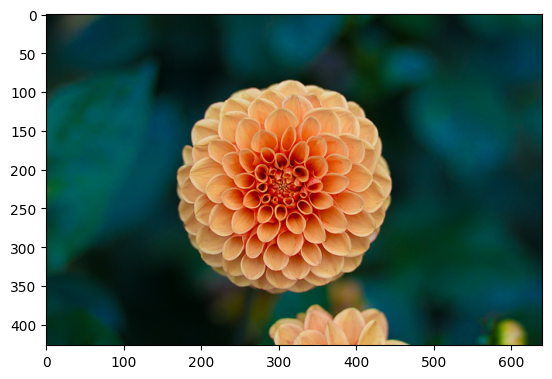

In [10]:
plt.imshow(norm_image)
plt.show()

Confirm that the image is still 3-dimentional (RBG) using 'assert'. If you don't get an error then d still equals 3.

In [11]:
## extract dimensions
norm_shape = tuple(norm_image.shape)
assert norm_shape[2] == 3

1.6 Reshape the normalised image into a [2-dimensional array](https://panjeh.medium.com/convert-numpy-3d-array-to-2d-array-in-python-931a4cdf8b12).

In [12]:
image_array = np.reshape(norm_image, (-1, d))

1.7 Shuffle the image array using a fixed random state (seed).

In [13]:
# Shuffle the image array using a fixed random state (seed)
image_sample = shuffle(image_array, random_state=42)

### 2. Clustering (using K-means)
https://towardsdatascience.com/how-to-perform-kmeans-clustering-using-python-7cc296cec092/

2.1 Specity the number of clusters (colours) you want.

In [32]:
n_colors = 4

2.2 Initialise and fit the K-means algorithm.

In [33]:
# Initialize and fit KMeans clustering on the image sample
kmeans = KMeans(n_clusters = n_colors)
kmeans.fit(image_sample)

KMeans(n_clusters=4)

2.3 Re-create the image using the clusters - map each pixel to it's cluster.

In [34]:
# Get the cluster number each pixel belongs to for the full image - use the model on the original image_array
labels = kmeans.predict(image_array)

2.4 Reconstruct the 2D array back to 3D.

What is the current shape of the cluster centers (kmeans.cluster_centers_)? Is d still the same value (3)?

In [35]:
kmeans.cluster_centers_.shape

(4, 3)

Reconstruct the image based on the cluster centers to the original (3D) shape.

In [36]:
## Get the accosiated cluster center for each predicted label (e.g. label 0 -> cluster center 0)
segmented_data = kmeans.cluster_centers_[labels]
## reshape the reconstructed array to original shape
recon_image = segmented_data.reshape((norm_image.shape))

###5. Visualisation

5.1 Visualize the cluster centers in 2D scatter plot.

In [37]:
kmeans.cluster_centers_

array([[0.03141995, 0.15190221, 0.11686562],
       [0.86300546, 0.62919522, 0.40007224],
       [0.008417  , 0.27953807, 0.28478676],
       [0.71340346, 0.29605145, 0.10966179]])

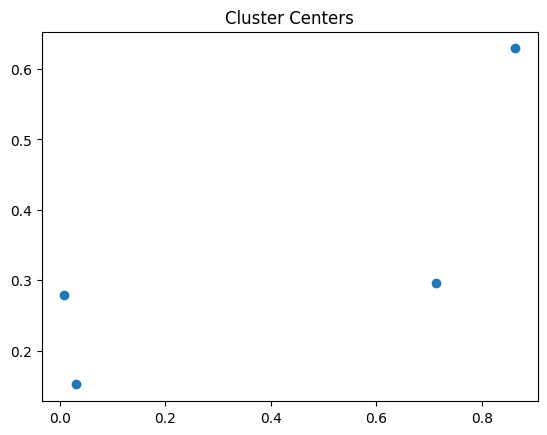

In [38]:
plt.figure()
plt.title('Cluster Centers')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1])
plt.show()

Display the reconstructed image.

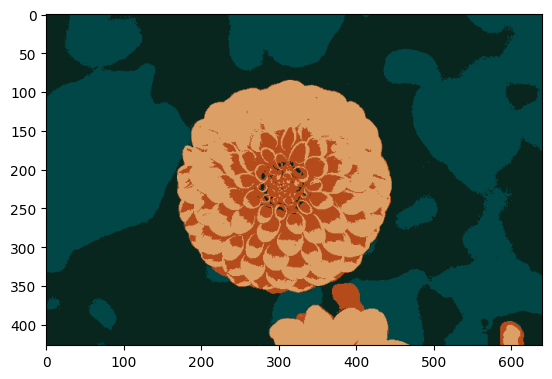

In [39]:
plt.imshow(recon_image)

5.3 Save the reconstructed image to google drive.

Hint: If your saved image shows only white or black, first plot the image, thens save (savefig) and only then use plt.show() (all in one cell).

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


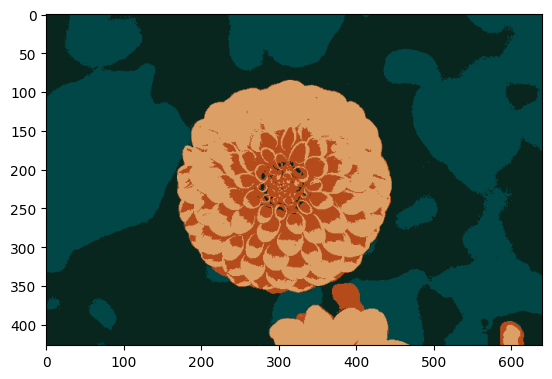

In [42]:
plt.imshow(recon_image)
plt.savefig("/content/drive/MyDrive/recon_image.png")
plt.show()